# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

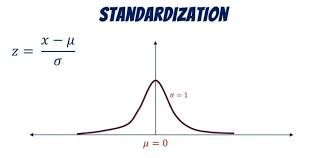


In [1]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
#loading the data
import csv
import numpy as np
data = np.genfromtxt("ObservationData_lavlqce-selected-columns.csv", delimiter=',', skip_header=1, usecols=range(2, 10), filling_values=np.nan)





In [2]:
#replace all the missing cells with the mean of the column
for i in range(data.shape[1]):
    mean = np.nanmean(data[:, i])
    data[np.isnan(data[:, i]), i] = mean


In [3]:
#stardazing data
mean = np.mean(data, axis=0)
std = np.std(data, axis=0)
standardized_data = (data - mean) / std
standardized_data

array([[ 3.76441182e-16,  2.70221539e-16, -3.74302829e-01, ...,
        -3.92182828e-01, -3.48422724e-01, -4.07416012e-01],
       [-2.40950841e-01, -1.73590685e+00, -3.79504358e-01, ...,
        -3.94286158e-01, -3.48303285e-01, -4.14386636e-01],
       [-2.08818843e-01, -2.45119062e-01, -3.78885053e-01, ...,
        -3.95999893e-01, -3.50253859e-01, -4.11661684e-01],
       ...,
       [-2.36363095e-01, -1.63873190e+00, -1.73155970e-01, ...,
        -1.68180807e-01,  2.87584986e-02, -3.60285736e-01],
       [-1.99545820e-01,  8.50050693e-02, -1.62804685e-01, ...,
        -1.58164951e-01,  5.55850816e-02, -3.53950585e-01],
       [-2.02647646e-01, -5.44011795e-02, -1.54997534e-01, ...,
        -1.48303591e-01,  7.26198866e-02, -3.47501986e-01]],
      shape=(2322, 8))

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [4]:
# Step 3: Calculate the Covariance Matrix
cov_matrix = standardized_data.T @ standardized_data / (standardized_data.shape[0] - 1)  # Calculate covariance matrix
cov_matrix

array([[ 1.00043085, -0.08205166, -0.08183198, -0.02690953, -0.0203023 ,
         0.14715861, -0.06750678,  0.04813326],
       [-0.08205166,  1.00043085,  0.00111996,  0.00378091, -0.00458189,
        -0.02454344,  0.00138976, -0.00118583],
       [-0.08183198,  0.00111996,  1.00043085,  0.94989189,  0.93082765,
         0.81577515,  0.91472206,  0.86715386],
       [-0.02690953,  0.00378091,  0.94989189,  1.00043085,  0.97838233,
         0.82972424,  0.96674167,  0.90660353],
       [-0.0203023 , -0.00458189,  0.93082765,  0.97838233,  1.00043085,
         0.83012451,  0.99227138,  0.88360929],
       [ 0.14715861, -0.02454344,  0.81577515,  0.82972424,  0.83012451,
         1.00043085,  0.75274674,  0.85055776],
       [-0.06750678,  0.00138976,  0.91472206,  0.96674167,  0.99227138,
         0.75274674,  1.00043085,  0.84980452],
       [ 0.04813326, -0.00118583,  0.86715386,  0.90660353,  0.88360929,
         0.85055776,  0.84980452,  1.00043085]])

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

The covarince helps find the direction of the maximum spread, it does does this by showing the variance of the data, hence showing the direction of the most useful information in the dataset. Secondly, the covarience matrix helps eliminate redundant information, it does this by spotting features that move together allowing us to reduce the dataset size without losing information.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [5]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)  # Perform eigendecomposition
eigenvalues, eigenvectors

(array([5.71653710e-05, 2.15769412e-02, 8.93553810e-02, 1.30330981e-01,
        2.66503869e-01, 9.36521796e-01, 1.11234572e+00, 5.44675493e+00]),
 array([[ 6.97687171e-03,  1.17959184e-02, -8.17426116e-02,
          1.18760486e-03, -2.29789029e-01, -5.85222421e-01,
          7.73200356e-01, -1.35783918e-03],
        [-2.74017382e-04,  5.29020100e-03,  7.13278778e-04,
         -1.20091933e-02, -1.83126621e-04, -7.97266928e-01,
         -6.03480359e-01, -2.01933194e-03],
        [-1.34737664e-03,  2.35570668e-01, -8.55675903e-01,
         -1.80776033e-01, -5.46587924e-02,  5.41773963e-02,
         -6.82820814e-02,  4.11166879e-01],
        [-1.50923870e-03, -8.86896740e-01, -2.87115823e-02,
          1.24843556e-02, -1.80388461e-01,  1.58623287e-02,
         -3.03721628e-02,  4.22750046e-01],
        [-7.52891301e-01,  2.42871962e-01,  3.23503340e-01,
         -1.58065317e-01, -2.56673265e-01,  2.05366265e-02,
         -2.24652337e-02,  4.21569968e-01],
        [ 1.42126760e-01,  9.40918

np.linalg.eigh(cov_matrix) is a python built in function for calculating eigen values and eigen vectors of a square matrix , the eigen values tell us how much varianvce or the spread that exists in the data  and the eigen vectors

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [6]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]
sorted_eigenvectors

array([[-1.35783918e-03,  7.73200356e-01, -5.85222421e-01,
        -2.29789029e-01,  1.18760486e-03, -8.17426116e-02,
         1.17959184e-02,  6.97687171e-03],
       [-2.01933194e-03, -6.03480359e-01, -7.97266928e-01,
        -1.83126621e-04, -1.20091933e-02,  7.13278778e-04,
         5.29020100e-03, -2.74017382e-04],
       [ 4.11166879e-01, -6.82820814e-02,  5.41773963e-02,
        -5.46587924e-02, -1.80776033e-01, -8.55675903e-01,
         2.35570668e-01, -1.34737664e-03],
       [ 4.22750046e-01, -3.03721628e-02,  1.58623287e-02,
        -1.80388461e-01,  1.24843556e-02, -2.87115823e-02,
        -8.86896740e-01, -1.50923870e-03],
       [ 4.21569968e-01, -2.24652337e-02,  2.05366265e-02,
        -2.56673265e-01, -1.58065317e-01,  3.23503340e-01,
         2.42871962e-01, -7.52891301e-01],
       [ 3.79461248e-01,  1.56989091e-01, -1.12938695e-01,
         7.40182010e-01, -4.52679886e-01,  2.13380883e-01,
         9.40918421e-03,  1.42126760e-01],
       [ 4.11563297e-01, -6.995110

In [7]:
eigenvalue_share = sorted_eigenvalues / np.sum(sorted_eigenvalues)
eigenvalue_share
cumulative_variance = np.cumsum(eigenvalue_share)


### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [8]:
# Step 6: Project Data onto Principal Components
my_threshold = 0.90
num_components = int(np.argmax(cumulative_variance >= my_threshold) + 1)  # Decide on the number of principal components to keep
W = sorted_eigenvectors[:, :num_components]
reduced_data = standardized_data @ W
reduced_data[:5]

array([[-0.9202381 , -0.01196066,  0.01157972],
       [-0.92221361,  0.84900737,  1.53687308],
       [-0.92712615, -0.02574174,  0.32942182],
       [-0.92506192, -0.22435286,  0.05697979],
       [-0.92906472, -0.20592453,  0.08741775]])

In [ ]:
# calculate the percentage of variance retained for each original column 
names = ["Per capita GDP growth", "Real GDP growth", "GDP (constant)",
                 "GDP (current)", "Final consumption", "Gov. consumption",
                 "Household consumption", "Gross capital formation"]
W = sorted_eigenvectors[:, :num_components]
reconstructed = standardized_data @ W @ W.T
lost = standardized_data - reconstructed

retained_pct = (1 - lost.var(axis=0) / standardized_data.var(axis=0)) * 100
for name, p in zip(names, retained_pct):
    print(f"{name:25s} {p:6.2f}% kept")

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [9]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

Reduced Data Shape: (2322, 3)


array([[-0.9202381 , -0.01196066,  0.01157972],
       [-0.92221361,  0.84900737,  1.53687308],
       [-0.92712615, -0.02574174,  0.32942182],
       [-0.92506192, -0.22435286,  0.05697979],
       [-0.92906472, -0.20592453,  0.08741775]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

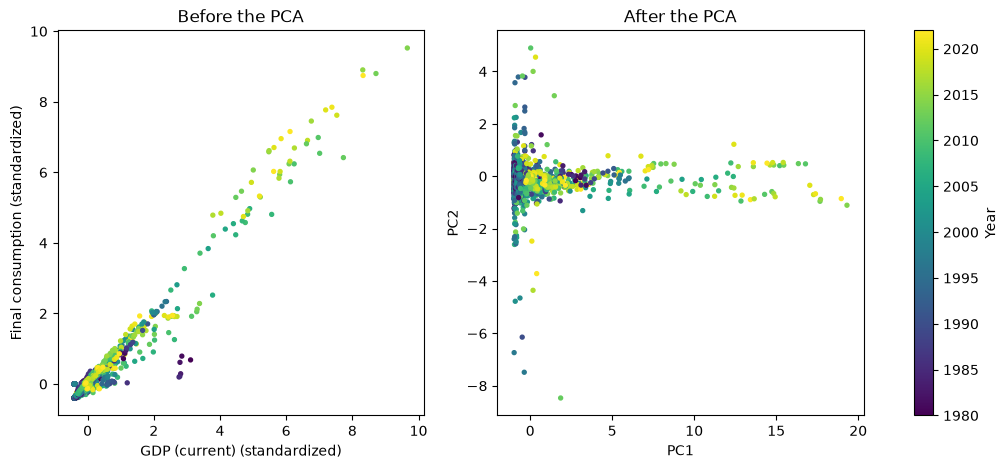

In [10]:
import matplotlib.pyplot as plt

#all the names of the numeric columns in the dataset
names = ["Per capita GDP growth", "Real GDP growth", "GDP (constant)",
                 "GDP (current)", "Final consumption", "Gov. consumption",
                 "Household consumption", "Gross capital formation"]

years = np.genfromtxt("ObservationData_lavlqce-selected-columns.csv", delimiter=',', skip_header=1, usecols=1)

#Before PCA plot
fig,ax = plt.subplots(1,2,figsize=(13,5))
ax[0].scatter(standardized_data[:,3],standardized_data[:, 4],c=years,s=8)
ax[0].set_xlabel(names[3] + " (standardized)")
ax[0].set_ylabel(names[4] + " (standardized)")
ax[0].set_title("Before the PCA")

#after the PCA
sc = ax[1].scatter(reduced_data[:, 0], reduced_data[:, 1], c=years, s=8)
ax[1].set_xlabel("PC1")
ax[1].set_ylabel("PC2")
ax[1].set_title("After the PCA")

fig.colorbar(sc, ax=ax, label="Year")
plt.show()


Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?


1. In the before PCA plot, GPD and consumption rise together in a straight line, this can mean they carry information of the same importance. And most of the points are near 0, and a few very large economies sit far out along the line. In After PCA plot (right), PC1 spreads for -1 -> 19, while PC2 spreads from mostly -2 -> 2, this shows that PC1 carries more variation. The points form a long tail along PC1, and the colours suggest the tail is mostly later years. The same 2,322 points are shown, but now each point's position uses information from all 8 columns.

2. For the principal components i set a 90% the threshold for my variance, and because of that the code returned 3 components which keeps 93% of the variance. This reduced the initial 8 columns to 3, which is worthwhile because six of the eight columns are size measures that move together.The trade-off is simplicity against detail: keeping only 3 discards 6.35% of the variance. A 95% threshold would need 4 components, giving more detail but less compression. I chose 90% as a balance between the two.

3. Reducing 8 columns to 3 components keeps 93.65% of the total variance, so 6.35% is lost from the original data. The loss is not spread evenly: Government consumption keeps only 82.33% of its variance and gross capital formation 88.21%, while the two growth rates keep 98.5% to 100%. This means PCA preserved the overall size of the economy and its growth, but loses how much a government spends or how much an economy invests beyond what its size predicts. Another cost is that each component blends several columns, so I can no longer read one variable, such as household consumption, directly from a given axis.